# 06 Task 2A: weekly demand forecast

**Purpose:** forecast total and chilled volume (m3) for each depot and brand for ISO weeks 14 to 23 of 2026. These are the weeks around New Year, Vesak and Poson, when reefer and truck capacity is tightest.

**The trap.** Festivals move between ISO weeks every year (notebook 01). Vesak was week 21 in 2024, week 20 in 2025 and is week 18 in 2026. Any method that copies "the same week last year" puts the festival spike in the wrong week.

**Our approach.** Forecast each day, then add the days up into ISO weeks. A daily model learns "the days before a festival are busy and the festival day is closed", so the weekly totals follow the 2026 calendar on their own. Two daily models are blended:
- a readable per-series regression on log volume with a growth trend and calendar effects
- one LightGBM across all series that learns the calendar shape on top of that trend

**Inputs:** clean orders (train and Task 1 test inputs), the calendar and the `not_run` uplift from notebook 03.

**Outputs:** `submissions/submission_task2a.csv`, `data/processed/task2a_forecast.parquet` with P10/P50/P90 ranges, and saved models in `models/`.

In [1]:
import json

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xora import forecast as fc
from xora.io import load_processed, save_processed
from xora.paths import MODELS, SUBMISSIONS, raw_file
from xora.plotting import apply_style, SERIES, INK, INK_SOFT

apply_style()
pd.set_option("display.width", 160)

orders = load_processed("orders")
calendar = load_processed("calendar")
weekly_table = load_processed("weekly_demand")

## 1. Daily demand panel

The counting rules match notebook 03's weekly table:
- every order counts once on its order date, including deferred and `not_run` orders
- weeks come from the calendar's `iso_year` and `iso_week`
- weeks 8 to 13 of 2026 come from the Task 1 test inputs, which leave out `not_run` orders, so they get the same small uplift as in notebook 03

Days with no orders are filled with zero, so Style and Tech, which do not order every day, are not overstated. Chilled is forecast only for Fresh; Style and Tech carry no chilled goods.

In [2]:
test_weeks = weekly_table[weekly_table.source == "test inputs"]
uplift = test_weeks.assign(
    factor_total=(test_weeks.total_volume_m3_adj / test_weeks.total_volume_m3).fillna(1.0),
    factor_chilled=(test_weeks.chilled_volume_m3_adj / test_weeks.chilled_volume_m3).fillna(1.0),
)[["depot", "brand", "iso_year", "iso_week", "factor_total", "factor_chilled"]]

panel = fc.daily_panel(orders, calendar, uplift)
weekly = fc.to_weeks(panel, ["y"])

# The daily panel must add back up to notebook 03's weekly table exactly
check = weekly.pivot_table(index=["depot", "brand", "iso_year", "iso_week"], columns="measure", values="y").fillna(0)
ref = weekly_table.set_index(["depot", "brand", "iso_year", "iso_week"])[["total_volume_m3_adj", "chilled_volume_m3_adj"]]
gap = (check[["total", "chilled"]].to_numpy() - ref.loc[check.index].to_numpy())
print(f"largest gap against the weekly table: {np.abs(gap).max():.6f} m3")
panel.groupby(fc.SERIES_KEYS, observed=True).agg(days=("y", "size"), mean_daily_m3=("y", "mean"), last_day=("date", "max"))

largest gap against the weekly table: 0.000000 m3


days  mean_daily_m3   last_day
depot      brand measure                                
Kandy      Fresh chilled   818      26.004836 2026-03-28
                 total     818      71.553423 2026-03-28
           Style total     818      11.584805 2026-03-28
           Tech  total     818       3.035246 2026-03-28
Peliyagoda Fresh chilled   818      50.387904 2026-03-28
                 total     818     136.754166 2026-03-28
           Style total     818      20.263391 2026-03-28
           Tech  total     818       4.258793 2026-03-28

## 2. Why "same week last year" fails

Peliyagoda Fresh is the largest series. Plotting each year against its ISO week shows the problem: the busy week before New Year and the dip in the festival week itself sit in different weeks every year.

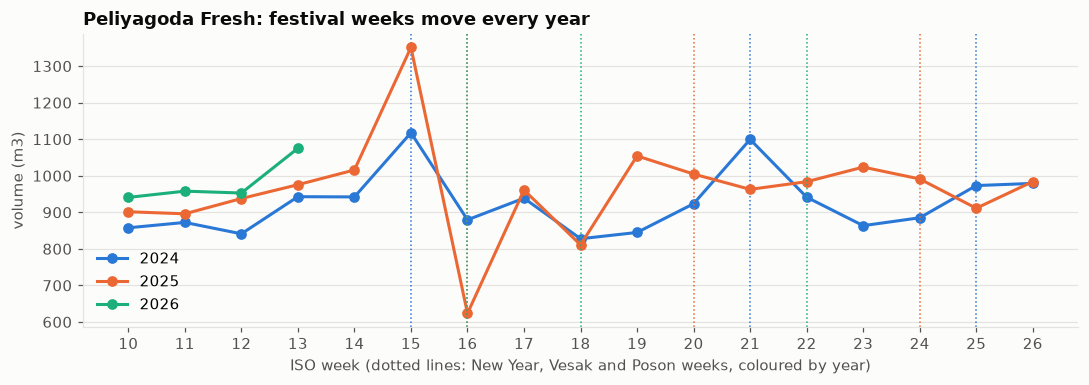

In [3]:
pf = weekly[(weekly.depot == "Peliyagoda") & (weekly.brand == "Fresh") & (weekly.measure == "total")]
fest_weeks = calendar[calendar.festival.isin(["new_year", "vesak", "poson"])][["iso_year", "iso_week", "festival"]]

fig, ax = plt.subplots(figsize=(10, 3.6))
for (year, g), color in zip(pf.groupby("iso_year"), SERIES):
    g = g[g.iso_week.between(10, 26)]
    ax.plot(g.iso_week, g.y, marker="o", markersize=6, color=color, label=str(year))
    for _, f in fest_weeks[fest_weeks.iso_year == year].iterrows():
        if 10 <= f.iso_week <= 26:
            ax.axvline(f.iso_week, color=color, linewidth=1, linestyle=":")
ax.set_xticks(range(10, 27))
ax.set_xlabel("ISO week (dotted lines: New Year, Vesak and Poson weeks, coloured by year)")
ax.set_ylabel("volume (m3)")
ax.set_title("Peliyagoda Fresh: festival weeks move every year")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

The 2026 lines stop at week 13 because that is where the forecast begins. New Year falls in week 15 in 2024 but week 16 in 2025 and 2026, and Vesak moves from week 21 to 20 to 18. A weekly model keyed on the week number would put each spike and dip in the wrong place.

## 3. The two daily models

**Regression (readable).** For each series, log daily volume is regressed on:
- a growth trend
- day of week and month
- festival ramp, payday, holiday and monsoon flags
- dummies for the 10 days before and 4 days after a festival

It is fitted on operating days only, because non-operating days are zero by definition. A small ridge penalty keeps the many calendar effects stable.

**Calendar LightGBM.** One model across all eight series learns the remaining calendar shape on top of the regression's growth trend: which festival is coming, how many days away it is, the day of year and so on. Trees cannot extrapolate a trend, so the trend comes from the regression and LightGBM only learns the shape around it.

In [4]:
reg_full = fc.TrendRegression().fit(panel)
growth = pd.Series({k: np.expm1(b[1]) for k, b in reg_full.coef.items()}, name="growth per year")
growth.index = growth.index.set_names(fc.SERIES_KEYS)
growth.to_frame().style.format("{:+.1%}")

The fitted growth rates match what notebook 01 found: a few percent a year for Fresh, and faster but noisier growth for Tech.

## 4. Backtests

Each backtest pretends to stand at a past Monday, trains only on data before it, and forecasts the next 10 weeks, the same shape as the real task. Six origins cover a full year, including the April festival window of 2025, which is the closest match to the real forecast.

Compared methods:
- **same week last year** (seasonal naive): the usual shortcut
- **recent average:** the mean of the last 8 weeks
- **regression**, **calendar LightGBM**, and a 50/50 **blend** of the two

Metrics, on weekly totals:
- **WAPE:** total absolute error over total volume, so big series count more, as they do for fleet planning
- **vs last year:** total absolute error divided by that of "same week last year" on the same weeks. Below 1 beats the shortcut.
- **bias:** whether a method runs high or low

In [5]:
ORIGINS = pd.to_datetime(["2025-01-06", "2025-03-31", "2025-06-30", "2025-09-29", "2025-12-01", "2026-01-19"])
HORIZON = pd.Timedelta(weeks=10)
METHODS = ["same week last year", "recent average", "regression", "calendar LightGBM", "blend"]

def backtest(origin):
    past = panel[panel.date < origin]
    future = panel[(panel.date >= origin) & (panel.date < origin + HORIZON)].copy()
    future["regression"] = fc.TrendRegression().fit(past).predict(future)
    future["calendar LightGBM"] = fc.CalendarGBM().fit(past).predict(future)
    wk = fc.to_weeks(future, ["y", "regression", "calendar LightGBM"])
    wk["blend"] = (wk["regression"] + wk["calendar LightGBM"]) / 2

    past_wk = fc.to_weeks(past, ["y"])
    last_year = past_wk.assign(iso_year=past_wk.iso_year + 1).rename(columns={"y": "same week last year"})
    wk = wk.merge(last_year, on=fc.SERIES_KEYS + ["iso_year", "iso_week"], how="left").fillna({"same week last year": 0})
    recent = past_wk.groupby(fc.SERIES_KEYS, observed=True).tail(8).groupby(fc.SERIES_KEYS, observed=True).y.mean()
    wk = wk.merge(recent.rename("recent average"), on=fc.SERIES_KEYS)

    wk["origin"] = origin.date()
    wk["horizon_week"] = wk.groupby(fc.SERIES_KEYS, observed=True).cumcount() + 1
    return wk

bt = pd.concat([backtest(o) for o in ORIGINS], ignore_index=True)

def scores(df):
    out = {}
    for m in METHODS:
        err = df[m] - df.y
        out[(m, "WAPE")] = err.abs().sum() / df.y.sum()
        out[(m, "vs last year")] = err.abs().sum() / (df["same week last year"] - df.y).abs().sum()
        out[(m, "bias")] = err.sum() / df.y.sum()
    return pd.Series(out)

overall = bt.groupby("measure").apply(scores).T.unstack(level=1)
overall.style.format({c: "{:.2f}" if c[1] == "vs last year" else "{:.1%}" for c in overall.columns})

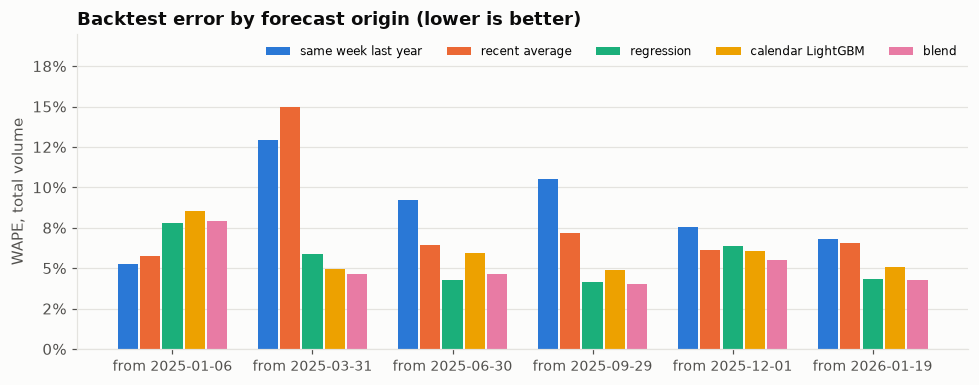

In [6]:
wape_by_origin = bt[bt.measure == "total"].groupby("origin").apply(
    lambda g: pd.Series({m: (g[m] - g.y).abs().sum() / g.y.sum() for m in METHODS}))

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(wape_by_origin))
width = 0.16
for i, (m, color) in enumerate(zip(METHODS, SERIES)):
    ax.bar(x + (i - 2) * width, wape_by_origin[m], width=width * 0.9, color=color, label=m)
ax.set_xticks(x, [f"from {o}" for o in wape_by_origin.index], fontsize=9)
ax.set_ylabel("WAPE, total volume")
ax.set_title("Backtest error by forecast origin (lower is better)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, wape_by_origin.to_numpy().max() * 1.3)
ax.legend(ncol=5, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

- **Same week last year is worst exactly where it matters.** In the April festival window (origin 31 March 2025) its error is about three times the blend's, because New Year and Vesak moved weeks.
- **The blend is best overall** for both total and chilled volume, and its bias is close to zero.
- The first origin (January 2025) has only one year of history, so the calendar effects are not settled yet and the simple shortcut wins there. From the April 2025 origin onward, with more history, the blend wins every time.